# Final Out-of-Sample Holdout Evaluation & Robustness
This notebook runs the final evaluation of the calibrated ensemble on the untouched holdout slice. We compute confidence intervals via bootstrapping, run cost-stress sensitivity tests, and export final model metrics.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, f1_score
import sys
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*feature names.*')
sys.path.append('../')
from src.feature_engineering import bootstrap_ci

ROOT = Path.cwd().parent
CSV = ROOT / 'csv_files'
OUT = ROOT / 'outputs'
ART = ROOT / 'model_artifacts'
SEED = 42
rng = np.random.default_rng(SEED)

## Load Model, Features, and Untouched Holdout Dataset

In [2]:
model = joblib.load(ART / 'final_calibrated_hgb_model.joblib')
features = pd.read_csv(ART / 'final_model_features.csv')['feature'].tolist()

hold_df = pd.read_csv(ROOT / 'data' / 'holdout_data.csv')
hold_df['timestamp_utc'] = pd.to_datetime(hold_df['timestamp_utc'])
print(f"Untouched Holdout Dataset: {len(hold_df)} rows")

Untouched Holdout Dataset: 31662 rows


## Generate Holdout Predictions and Calibrated Decision Rules
We apply the optimized threshold and sizing parameters (`thr=0.52`, `alpha=0.75`, `gate=0.05`).

In [3]:
p_hold = model.predict_proba(hold_df[features])[:, 1]
thr, alpha, gate = 0.52, 0.75, 0.05

conf = np.clip((p_hold - thr) / (1 - thr), 0, 1)
size = conf ** alpha
take = (p_hold >= thr) & (np.abs(p_hold - thr) >= gate)
pnl_taken = hold_df['Closed PnL'].values * size * take
eq = pnl_taken.cumsum()
dd = eq - np.maximum.accumulate(eq)

hold_eval = hold_df[['timestamp_utc', 'date_utc', 'Account', 'Coin', 'fg_classification', 'Size USD']].copy()
hold_eval['y'] = hold_df['y'].values
hold_eval['p'] = p_hold
hold_eval['take'] = take.astype(int)
hold_eval['conf'] = conf
hold_eval['size'] = size
hold_eval['pnl'] = hold_df['Closed PnL'].values
hold_eval['pnl_taken'] = pnl_taken
hold_eval['equity'] = eq
hold_eval['drawdown'] = dd

hold_eval.to_csv(CSV / 'final_holdout_oof.csv', index=False)
hold_eval.to_csv(ROOT / 'data' / 'final_holdout_oof.csv', index=False)
print("Holdout predictions exported.")

Holdout predictions exported.


## Calculate Performance Summary Table

In [4]:
summary = pd.DataFrame([{
    'model': 'final_holdout_calibrated_ensemble',
    'best_threshold': thr,
    'best_alpha': alpha,
    'best_gate': gate,
    'holdout_rows': len(hold_df),
    'taken_trades': int(take.sum()),
    'total_pnl': float(pnl_taken.sum()),
    'max_drawdown': float(dd.min()),
    'hit_rate': float((((hold_df['y'].values == 1) & take).sum()) / max(1, take.sum())),
    'profit_factor': float((pnl_taken[pnl_taken > 0].sum() / (-pnl_taken[pnl_taken < 0].sum())) if (-pnl_taken[pnl_taken < 0].sum()) > 0 else np.nan),
    'holdout_roc_auc': float(roc_auc_score(hold_df['y'].values, p_hold)),
    'holdout_pr_auc': float(average_precision_score(hold_df['y'].values, p_hold)),
    'holdout_brier': float(brier_score_loss(hold_df['y'].values, p_hold)),
}])
summary.to_csv(CSV / 'final_holdout_summary.csv', index=False)
summary.to_csv(ROOT / 'data' / 'final_holdout_summary.csv', index=False)
summary

,model,best_threshold,best_alpha,best_gate,holdout_rows,taken_trades,total_pnl,max_drawdown,hit_rate,profit_factor,holdout_roc_auc,holdout_pr_auc,holdout_brier
0,final_holdout_calibrated_ensemble,0.52,0.75,0.05,31662,11633,1.034276e+06,-1825.80154,0.960028,66.598048,0.994003,0.97666,0.017807


## Run Cost-Stress sensitivity Tests
We evaluate trading performance decay under trading costs from 0 bps to 50 bps.

In [5]:
stress_rows = []
for bps in [0, 5, 10, 20, 30, 50]:
    extra_cost = hold_eval['Size USD'].values * hold_eval['take'].values * (bps / 10000.0)
    stressed = hold_eval['pnl_taken'].values - extra_cost
    eq_s = stressed.cumsum()
    dd_s = eq_s - np.maximum.accumulate(eq_s)
    gp = stressed[stressed > 0].sum()
    gl = -stressed[stressed < 0].sum()
    stress_rows.append({
        'extra_cost_bps': bps,
        'total_pnl': float(stressed.sum()),
        'max_drawdown': float(dd_s.min()),
        'profit_factor': float(gp / gl) if gl > 0 else np.nan
    })
stress_df = pd.DataFrame(stress_rows)
stress_df.to_csv(CSV / 'final_holdout_cost_stress.csv', index=False)
stress_df.to_csv(ROOT / 'data' / 'final_holdout_cost_stress.csv', index=False)
stress_df

,extra_cost_bps,total_pnl,max_drawdown,profit_factor
0,0,1.034276e+06,-1825.801540,66.598048
1,5,9.512056e+05,-1842.882620,50.218483
2,10,8.681355e+05,-7312.985688,27.069408
3,20,7.019951e+05,-25831.432798,11.211604
4,30,5.358548e+05,-44349.879908,5.205567
5,50,2.035740e+05,-90661.590351,1.659448


## Plot Holdout Performance Diagnostic Plots
We generate holdout reliability calibration curve, equity curve under costs, and stress curves.

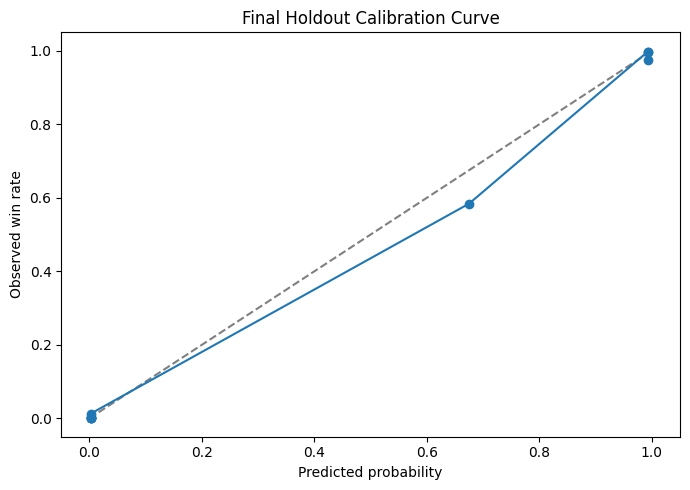

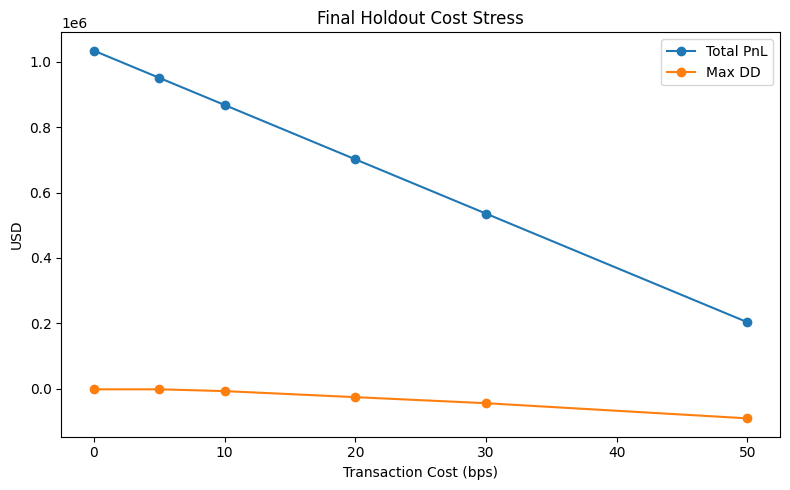

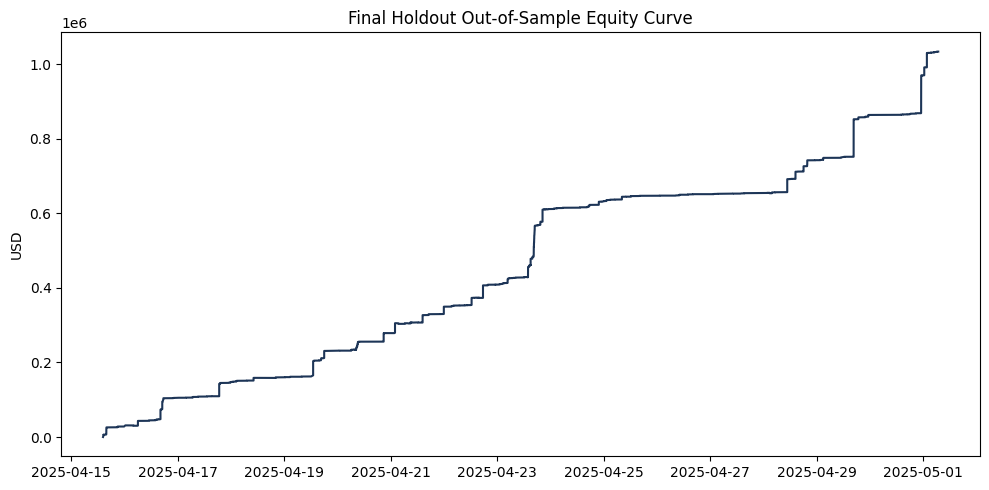

In [6]:
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(hold_eval['y'], hold_eval['p'], n_bins=10, strategy='quantile')
cal_df = pd.DataFrame({'predicted_probability_bin': prob_pred, 'observed_win_rate': prob_true})
cal_df.to_csv(CSV / 'final_holdout_calibration_curve.csv', index=False)

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.plot(prob_pred, prob_true, marker='o')
plt.title('Final Holdout Calibration Curve')
plt.xlabel('Predicted probability')
plt.ylabel('Observed win rate')
plt.tight_layout()
plt.savefig(OUT / 'figures/final_holdout_calibration_curve.png', dpi=180, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(stress_df['extra_cost_bps'], stress_df['total_pnl'], marker='o', label='Total PnL')
plt.plot(stress_df['extra_cost_bps'], stress_df['max_drawdown'], marker='o', label='Max DD')
plt.title('Final Holdout Cost Stress')
plt.xlabel('Transaction Cost (bps)')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.savefig(OUT / 'figures/final_holdout_cost_stress.png', dpi=180, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hold_eval['timestamp_utc'], hold_eval['equity'], color='#1d3557')
plt.title('Final Holdout Out-of-Sample Equity Curve')
plt.ylabel('USD')
plt.tight_layout()
plt.savefig(OUT / 'figures/model_oos_equity_drawdown_holdout.png', dpi=180)
plt.show()